In [1]:
# ===============================================================================================
# ===============================================================================================
#
# Grover_Simulacion.ipynb
#
# Emulador matemático de un computador cuántico a partir de una librería de funciones (puertas)
# Estructura secuencial (circuito) y formulación de vectores de estado. 
# Simulación cuántica del algoritmo de Grover a partir de oráculo y operador de dispersión 
# codificados en clave de puertas. Aplicado para la resolución de un Sudoku 2x2.
# 
#
# @author Antonio Ramírez Prieto
# 
# Simulación para TFG en el Grado en Física
#
# ===============================================================================================
# ===============================================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ============================================================
# PARTE I: ARQUITECTURA CIRCUITO / BACKEND
# ============================================================

class CircuitoCuantico:
    """Lista de puertas e instrucciones. No se realizan cálculos"""

    def __init__(self, n_qubits):
        self.n = n_qubits
        self.instrucciones = []

    # Puertas de 1 qubit
    def H(self, q):    self.instrucciones.append(('H', q))
    def X(self, q):    self.instrucciones.append(('X', q))
    def Z(self, q):    self.instrucciones.append(('Z', q))

    # Puertas de varios qubits
    def CNOT(self, c, t):       self.instrucciones.append(('CNOT', c, t))
    def CCNOT(self, c1, c2, t): self.instrucciones.append(('CCNOT', c1, c2, t))

    def barrera(self, etiqueta=None):
        self.instrucciones.append(('BARRERA', etiqueta))

    def __repr__(self):
        n_puertas = sum(1 for i in self.instrucciones if i[0] != 'BARRERA')
        return f"CircuitoCuantico(n={self.n}, puertas={n_puertas})"


# Matrices unitarias de las puertas de 1 q
_PUERTAS_1Q = {
    'H': np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2),
    
    'X': np.array([[0, 1], [1, 0]], dtype=complex),
    
    'Z': np.array([[1, 0], [0, -1]], dtype=complex),
}


def _perm_cnot(n, controles, objetivo):
    """Permutación de índices (puerta CNOT)"""
    idx = np.arange(2**n)
    mascara = np.ones(2**n, dtype=bool)
    
    for c in controles:
        mascara &= ((idx >> (n - 1 - c)) & 1).astype(bool)
    return np.where(mascara, idx ^ (1 << (n - 1 - objetivo)), idx)


class SimuladorVectorEstado:
    """Definición del vector de estado e instrucciones del circuito.
    (Backend de la simulación)"""

    def __init__(self):
        self.estado = None
        self.n = 0

    def ejecutar(self, circuito):
        """Inicializa en /ket{00...0}"""
        self.n = circuito.n
        N = 2**self.n
        self.estado = np.zeros(N, dtype=complex)
        self.estado[0] = 1.0
        
        """Recorre todas las instrucciones"""
        for instr in circuito.instrucciones:
            self._aplicar(instr)
        return self.estado

    def _aplicar(self, instr):
        tipo = instr[0]
        if tipo in _PUERTAS_1Q:
            self._puerta_1q(_PUERTAS_1Q[tipo], instr[1])
        elif tipo == 'CNOT':
            perm = _perm_cnot(self.n, [instr[1]], instr[2])
            self.estado = self.estado[perm]
        elif tipo == 'CCNOT':
            perm = _perm_cnot(self.n, [instr[1], instr[2]], instr[3])
            self.estado = self.estado[perm]
        elif tipo == 'BARRERA':
            pass
        else:
            raise ValueError(f"Instrucción desconocida: {tipo}")

    def _puerta_1q(self, U, qubit):
        """Toma el vect de estaod como tensor y aplica U (2x2) sobre el qubit n """
        n = self.n
        izq, der = 2**qubit, 2**(n - 1 - qubit)
        psi = self.estado.reshape(izq, 2, der)
        psi = np.tensordot(U, psi, axes=([1], [1]))
        psi = np.moveaxis(psi, 0, 1)
        self.estado = np.ascontiguousarray(psi).reshape(2**n)

    def medir(self):
        """Medida proyectiva: devuelve el índice del resultado y colapsa el estado"""
        probs = np.abs(self.estado)**2
        probs /= probs.sum()
        resultado = int(np.random.choice(len(self.estado), p=probs))
        self.estado = np.zeros(len(self.estado), dtype=complex)
        self.estado[resultado] = 1.0
        return resultado

    def probabilidades(self):
        """Probabilidad como cuadrado de la amplitud"""
        return np.abs(self.estado)**2

    def norma(self):
        """Norma de la probabilidad (debe mantenerse 1 al final de todas las ejecuciones)"""
        return float(np.real(np.dot(self.estado.conj(), self.estado)))


In [11]:
# ============================================================
# PARTE II: PROBLEMA CLÁSICO DEL SUDOKU 2×2
# ============================================================
#
# Cuadrícula 2x2, valores en {0,1} 
# (qubit 0, celda 1; qubit 1, celda 2).
# q0=c00, q1=c01, q2=c10, q3=c11
#
# Restricciones por fila c00 \neq c01,  c10 \neq c11 
# Restricciones por col  c00 \neq c10,  c01 \neq c11

def encontrar_soluciones():
    """Métodoo clásico: devuelve los índices {0..15} que son solución al problema"""
    soluciones = []
    
    for x in range(16):
        b = [(x >> (3 - i)) & 1 for i in range(4)]
        c00, c01, c10, c11 = b
        if c00 != c01 and c10 != c11 and c00 != c10 and c01 != c11:
            soluciones.append(x)
                             
    return soluciones

# ============================================================
# PARTE III: ORÁCULO, DIFUSIÓN Y CIRCUITO DE GROVER
# ============================================================
#
# Circuito de 11 qubits
#   q0..q3  como registro principal (c00,c01,c10,c11)
#   q4..q7  son ancillas XOR (una por restricción)
#   q8,q9   son ancillas AND
#   q10     es ancilla de fase (se inicializa en \ket{-})

N_TOTAL    = 11
N_PRINCIPAL = 4
REGISTRO   = (0, 1, 2, 3)
XOR_ANC    = (4, 5, 6, 7)
AND_ANC    = (8, 9)
FASE_ANC   = 10


def oraculo_sudoku(c):
    """Oráculo del problema Sudoku 2x2

    Implementa f(c00,c01,c10,c11) = (f0 XOR f1 XOR c0 XOR c1)
    
    1. XOR de cada restricción (CNOT sobre ancilla en /ket{0})
    2. AND par a par (CCNOT sobre ancilla en /ket{0})
    3. Phase kickback: fase -1 si solución
    4. Descomputación
    """
    q0, q1, q2, q3 = REGISTRO
    a_f0, a_f1, a_c0, a_c1 = XOR_ANC
    b0, b1 = AND_ANC

    # Paso 1: CNOT
    c.CNOT(q0, a_f0); c.CNOT(q1, a_f0)   # a_f0 = q0 XOR q1  (fila 0)
    c.CNOT(q2, a_f1); c.CNOT(q3, a_f1)   # a_f1 = q2 XOR q3  (fila 1)
    c.CNOT(q0, a_c0); c.CNOT(q2, a_c0)   # a_c0 = q0 XOR q2  (col 0)
    c.CNOT(q1, a_c1); c.CNOT(q3, a_c1)   # a_c1 = q1 XOR q3  (col 1)

    # Paso 2: CCNOT (AND)
    c.CCNOT(a_f0, a_f1, b0)               # b0 = a_f0 AND a_f1
    c.CCNOT(a_c0, a_c1, b1)               # b1 = a_c0 AND a_c1

    # Paso 3: phase kickback
    c.CCNOT(b0, b1, FASE_ANC)

    # Paso 4: descomputación (orden inverso)
    c.CCNOT(a_c0, a_c1, b1)
    c.CCNOT(a_f0, a_f1, b0)
    c.CNOT(q3, a_c1); c.CNOT(q1, a_c1)
    c.CNOT(q2, a_c0); c.CNOT(q0, a_c0)
    c.CNOT(q3, a_f1); c.CNOT(q2, a_f1)
    c.CNOT(q1, a_f0); c.CNOT(q0, a_f0)


def operador_difusion(c):
    """Implementa el operador de difusión del algoritmo
    Reutiliza q4,q5 como ancillas (están en /ket{0} tras el oráculo).
    """
    anc_a, anc_b = XOR_ANC[0], XOR_ANC[1]

    for q in REGISTRO: c.H(q)
    for q in REGISTRO: c.X(q)

    # Z multicontrolada por 4 qubits
    c.CCNOT(REGISTRO[0], REGISTRO[1], anc_a)
    c.CCNOT(REGISTRO[2], REGISTRO[3], anc_b)
    c.CCNOT(anc_a, anc_b, FASE_ANC)

    # Descomputación
    c.CCNOT(REGISTRO[2], REGISTRO[3], anc_b)
    c.CCNOT(REGISTRO[0], REGISTRO[1], anc_a)

    for q in REGISTRO: c.X(q)
    for q in REGISTRO: c.H(q)


def construir_circuito_grover(R):
    """Operador de Grover R iteraciones"""
    circ = CircuitoCuantico(N_TOTAL)

    # Ancilla de fase en \ket{-}
    circ.X(FASE_ANC); circ.H(FASE_ANC)

    # Superposición uniforme sobre el registro
    for q in REGISTRO: circ.H(q)

    for _ in range(R):
        oraculo_sudoku(circ)
        operador_difusion(circ)

    return circ


def prob_marginal_registro(estado):
    """Hasta aquí tengo un vector de N = 2^11 amplitudes, lo pliego para devolver
    las 2^4 que me interesan, axis=1 y limpiar las residuales"""
    
    psi = estado.reshape(2**N_PRINCIPAL, 2**(N_TOTAL - N_PRINCIPAL))
    return np.sum(np.abs(psi)**2, axis=1)




In [13]:

# ============================================================
# PARTE IV: ALGORITMO DE GROVER (ejecución)
# ============================================================

def algoritmo_grover(soluciones, verbose=True):
    """Ejecuta el algoritmo de Grover para el Sudoku 2x2
    Empleamos el valor M obtenido por el método clásico 
    (hardcodeamos el número de soluciones)"""
    
    N = 2**N_PRINCIPAL
    M = len(soluciones)
    R = max(1, int(round((np.pi / 4) * np.sqrt(N / M))))

    # Log de la simulación
    if verbose:
        print(f"\n{'='*55}")
        print(" ALGORITMO DE GROVER — Sudoku 2×2")
        print(f"{'='*55}")
        print(f"  Qubits registro : {N_PRINCIPAL}  |  Espacio : N = {N}")
        print(f"  Soluciones      : M = {M}")
        print(f"  Iteraciones     : R = {R}  (π/4·√(N/M) = {(np.pi/4)*np.sqrt(N/M):.2f})")
        print(f"  Complejidad     : clásica O({N}), cuántica O(√{N}≈{np.sqrt(N):.1f})")
        print(f"{'-'*55}")

    backend = SimuladorVectorEstado()
    historial = []

    for k in range(R + 1):
        estado_k = backend.ejecutar(construir_circuito_grover(k))
        probs_k = prob_marginal_registro(estado_k)
        p_sol = float(np.sum(probs_k[soluciones]))
        historial.append(p_sol)
        if verbose:
            label = "inicial" if k == 0 else f"iter {k}"
            print(f"  k={k} ({label}): P(solución) = {p_sol:.6f}  |norma| = {backend.norma():.10f}")

    # Ejecutar el circuito final para la medida
    backend.ejecutar(construir_circuito_grover(R))
    probs_finales = prob_marginal_registro(backend.estado)
    probs_iniciales = historial[0]   # solo el escalar, las probs se guardan abajo

    # Ejecutamos k=0 para guardar distribución inicial
    probs_ini_dist = prob_marginal_registro(SimuladorVectorEstado().ejecutar(construir_circuito_grover(0)))

    medido_total = backend.medir()
    idx_registro = medido_total >> (N_TOTAL - N_PRINCIPAL)
    correcto = idx_registro in soluciones

    if verbose:
        print(f"\n  Medida: |{format(idx_registro,'04b')}> (índice {idx_registro})"
              f" → {'✓ solución' if correcto else '✗ no es solución'}")
        print(f"{'='*55}\n")

    return {
        'resultado'       : idx_registro,
        'correcto'        : correcto,
        'probs_iniciales' : probs_ini_dist,
        'probs_finales'   : probs_finales,
        'historial'       : historial,
        'iteraciones'     : R,
    }



In [15]:

# ============================================================
# PARTE V: VISUALIZACIÓN
# ============================================================
# Apartado generado por un motor de inteligencia artificial para la representación gráfica
# de los resultados de la simulación.

def graficar_resultados(res, soluciones):
    """Distribuciones de probabilidad e historial de amplificación."""
    N = 2**N_PRINCIPAL
    estados = [format(x, '04b') for x in range(N)]
    colores = ['#c0392b' if i in soluciones else '#2980b9' for i in range(N)]

    fig = plt.figure(figsize=(13, 9))
    fig.suptitle("Algoritmo de Grover — Resolución del Sudoku 2×2",
                 fontsize=14, fontweight='bold', y=0.98)
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.35)

    # (a) Distribución inicial
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.bar(range(N), res['probs_iniciales'], color=colores, edgecolor='white')
    ax1.axhline(1/N, color='gray', linestyle='--', linewidth=1, label=f'1/N={1/N:.3f}')
    ax1.set_title(r'(a) Distribución inicial  $H^{\otimes 4}|0\rangle$', fontsize=11)
    ax1.set_xlabel('Estado $|x\\rangle$'); ax1.set_ylabel('Probabilidad')
    ax1.set_xticks(range(N)); ax1.set_xticklabels(estados, rotation=45, fontsize=7)
    ax1.set_ylim(0, 0.25); ax1.legend(fontsize=8)

    # (b) Distribución final
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(range(N), res['probs_finales'], color=colores, edgecolor='white')
    ax2.axhline(1/N, color='gray', linestyle='--', linewidth=1, label=f'1/N={1/N:.3f}')
    ax2.set_title(f'(b) Distribución tras {res["iteraciones"]} iteración(es)', fontsize=11)
    ax2.set_xlabel('Estado $|x\\rangle$'); ax2.set_ylabel('Probabilidad')
    ax2.set_xticks(range(N)); ax2.set_xticklabels(estados, rotation=45, fontsize=7)
    ax2.set_ylim(0, 1.05); ax2.legend(fontsize=8)
    for s in soluciones:
        ax2.annotate(f'{res["probs_finales"][s]:.3f}',
                     xy=(s, res['probs_finales'][s] + 0.02),
                     ha='center', fontsize=8, color='#c0392b', fontweight='bold')

    # (c) Historial de P(solución)
    ax3 = fig.add_subplot(gs[1, :])
    iters = range(len(res['historial']))
    ax3.plot(iters, res['historial'], 'o-', color='#27ae60', linewidth=2,
             markersize=8, markerfacecolor='white', markeredgewidth=2,
             label='$P(\\text{solución})$')
    ax3.axhline(1.0, color='gray', linestyle=':', linewidth=1)
    ax3.axhline(1/N, color='#95a5a6', linestyle='--', linewidth=1, label=f'1/N={1/N:.3f}')
    for i, p in enumerate(res['historial']):
        ax3.annotate(f'{p:.4f}', xy=(i, p), xytext=(0, 10),
                     textcoords='offset points', ha='center', fontsize=9)
    ax3.set_title(r'(c) Amplificación de amplitudes: $P(\text{solución})$ vs iteraciones', fontsize=11)
    ax3.set_xlabel('Iteraciones $k$'); ax3.set_ylabel('$P(\\text{solución})$')
    ax3.set_xticks(list(iters))
    ax3.set_xticklabels([f'k={i}' for i in iters])
    ax3.set_ylim(-0.05, 1.15); ax3.legend(fontsize=9); ax3.grid(axis='y', alpha=0.3)

    # plt.savefig('/mnt/user-data/outputs/grover_resultados.png', dpi=150, bbox_inches='tight')
    plt.show()


def graficar_rotacion_grover(soluciones, R_max=8):
    """Geometría del algoritmo de Grover en el plano |α>-|β>."""
    N = 2**N_PRINCIPAL
    M = len(soluciones)
    theta_medio = np.arcsin(np.sqrt(M / N))   # ángulo inicial = arcsin(√(M/N))
    R_opt = max(1, int(round(np.pi / (4 * theta_medio))))

    iters = np.arange(0, R_max + 1)
    p_exito = np.sin((2 * iters + 1) * theta_medio)**2

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Geometría de Grover  (N={N}, M={M},  θ={np.degrees(2*theta_medio):.1f}°)',
                 fontsize=13)

    # Rotación en el plano
    for k in range(min(R_max + 1, R_opt + 3)):
        ang = (2 * k + 1) * theta_medio
        color = plt.cm.plasma(k / R_max)
        ax1.annotate('', xy=(np.cos(ang), np.sin(ang)), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
        ax1.text(np.cos(ang) * 1.1, np.sin(ang) * 1.1, f'k={k}', fontsize=8, color=color, ha='center')
    ax1.set_xlim(-0.1, 1.35); ax1.set_ylim(-0.1, 1.35)
    ax1.set_xlabel(r'$|\alpha\rangle$ (no soluciones)'); ax1.set_ylabel(r'$|\beta\rangle$ (soluciones)')
    ax1.set_title(r'Rotación en el plano $|\alpha\rangle$-$|\beta\rangle$')
    ax1.axhline(0, color='k', lw=0.8); ax1.axvline(0, color='k', lw=0.8); ax1.grid(alpha=0.2)

    # P(éxito) vs iteraciones
    ax2.plot(iters, p_exito, 's--', color='#8e44ad', linewidth=2,
             markersize=8, markerfacecolor='white', markeredgewidth=2)
    ax2.axvline(R_opt, color='#e74c3c', linestyle=':', lw=1.5, label=f'R óptimo = {R_opt}')
    ax2.axhline(1.0, color='gray', linestyle=':', lw=1, alpha=0.5)
    for k, p in zip(iters, p_exito):
        ax2.annotate(f'{p:.3f}', xy=(k, p), xytext=(0, 8),
                     textcoords='offset points', ha='center', fontsize=8)
    ax2.set_xlabel('Iteraciones $k$')
    ax2.set_ylabel(r'$P(\text{éxito}) = \sin^2\!\left(\frac{2k+1}{2}\theta\right)$')
    ax2.set_title('Probabilidad de éxito vs iteraciones')
    ax2.set_ylim(-0.05, 1.15); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

    plt.tight_layout()
    # plt.savefig('/mnt/user-data/outputs/grover_geometria.png', dpi=150, bbox_inches='tight')
    plt.show()



Soluciones del Sudoku 2×2 (M=2):
  idx= 6 | 0110 | [1 2] / [2 1]
  idx= 9 | 1001 | [2 1] / [1 2]

 ALGORITMO DE GROVER — Sudoku 2×2
  Qubits registro : 4  |  Espacio : N = 16
  Soluciones      : M = 2
  Iteraciones     : R = 2  (π/4·√(N/M) = 2.22)
  Complejidad     : clásica O(16), cuántica O(√16≈4.0)
-------------------------------------------------------
  k=0 (inicial): P(solución) = 0.125000  |norma| = 1.0000000000
  k=1 (iter 1): P(solución) = 0.781250  |norma| = 1.0000000000
  k=2 (iter 2): P(solución) = 0.945312  |norma| = 1.0000000000

  Medida: |0110> (índice 6) → ✓ solución

Cuadrícula medida:  | 1 2 |
                    | 2 1 |
¿Solución válida? SÍ

Análisis estadístico (1000 ejecuciones):
  Éxitos: 948/1000  (94.8%)
  P(éxito) teórica: 0.9453

Verificación del oráculo:
  Estados marcados por el oráculo : [6, 9]
  Soluciones clásicas             : [6, 9]
  Coincidencia: True
  Ancillas a |0> tras oráculo     : True
  Norma: 1.000000000000


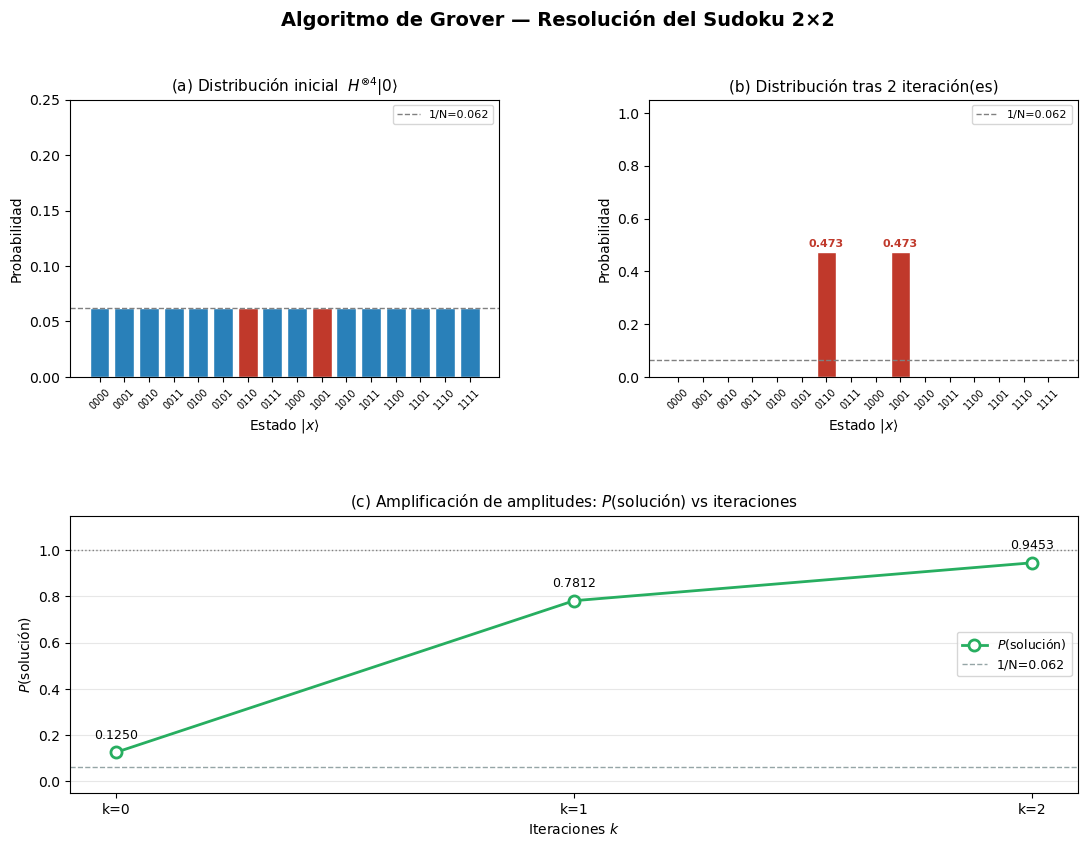

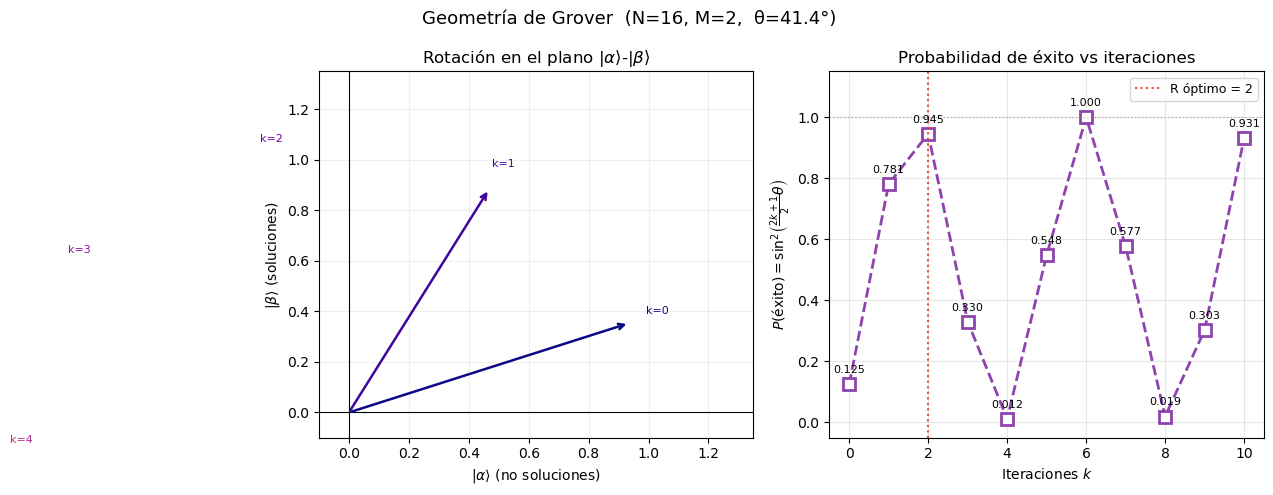

In [17]:

# ===========================================================
# EJECUCIÓN DE LA SIMULACIÓN
# ============================================================

if __name__ == '__main__':
    np.random.seed(42)

    # Resolución clásica del problema
    soluciones = encontrar_soluciones()
    print(f"Soluciones del Sudoku 2×2 (M={len(soluciones)}):")
    for s in soluciones:
        vals = [(s >> (3 - i)) & 1 + 1 for i in range(4)]
        vals = [((s >> (3 - i)) & 1) + 1 for i in range(4)]
        print(f"  idx={s:2d} | {format(s,'04b')} | [{vals[0]} {vals[1]}] / [{vals[2]} {vals[3]}]")

    # Resolución cuántica del problema por el algoritmo de Grover
    resultado = algoritmo_grover(soluciones, verbose=True)

    # Verificación del resultado
    idx = resultado['resultado']
    bits = [(idx >> (3 - i)) & 1 for i in range(4)]
    vals = [b + 1 for b in bits]
    print(f"Cuadrícula medida:  | {vals[0]} {vals[1]} |\n"
          f"                    | {vals[2]} {vals[3]} |")
    print(f"¿Solución válida? {'SÍ' if resultado['correcto'] else 'NO'}")

    # Análisis estadístico. 100 iteraciones
    N_runs = 1000
    exitos = sum(algoritmo_grover(soluciones, verbose=False)['correcto'] for _ in range(N_runs))
    print(f"\nAnálisis estadístico ({N_runs} ejecuciones):")
    print(f"  Éxitos: {exitos}/{N_runs}  ({100*exitos/N_runs:.1f}%)")
    print(f"  P(éxito) teórica: {np.sum(resultado['probs_finales'][soluciones]):.4f}")

    # Verificación final del oráculo
    circ_test = CircuitoCuantico(N_TOTAL)
    circ_test.X(FASE_ANC); circ_test.H(FASE_ANC)
    for q in REGISTRO: circ_test.H(q)
    oraculo_sudoku(circ_test)
    sve = SimuladorVectorEstado()
    estado_or = sve.ejecutar(circ_test)
    psi = estado_or.reshape(2**N_PRINCIPAL, 2**(N_TOTAL - N_PRINCIPAL))
    marcados = [x for x in range(16) if np.real(psi[x, 0]) < 0]
    print(f"\nVerificación del oráculo:")
    print(f"  Estados marcados por el oráculo : {marcados}")
    print(f"  Soluciones clásicas             : {soluciones}")
    print(f"  Coincidencia: {marcados == soluciones}")
    print(f"  Ancillas a |0> tras oráculo     : {np.allclose(psi[:, 2:], 0)}")
    print(f"  Norma: {sve.norma():.12f}")

    # Representación
    graficar_resultados(resultado, soluciones)
    graficar_rotacion_grover(soluciones, R_max=10)